# 03 · SFT 微调（Qwen2.5 + LoRA）

> 对应 JD 关键词：**SFT、PEFT/LoRA**。对应你 T5 项目的"全量微调"——这次换成 **decoder-only 大模型 + LoRA 高效微调**。

## LoRA vs 全量微调
- 全量微调：更新模型**所有**参数，开销大。
- LoRA：冻结原模型，只在每层旁加一对**低秩小矩阵**训练，**只更新约 0.1%~1% 参数**，单卡可跑。


In [4]:
import os, json, sys   # os=文件/路径操作, json=读写json数据, sys=系统相关
import torch           # PyTorch：深度学习框架(模型和张量都靠它)

# 走国内镜像下模型，比 huggingface.co 官方站快很多（几 MB/s vs 几百 kB/s）。
# 必须在 import transformers 之前设置才生效，所以放在最顶部。
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

# 自动找到项目根目录（notebooks 文件夹的上一级）
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
DATA = os.path.join(ROOT, "data")      # data 目录完整路径
OUT  = os.path.join(ROOT, "outputs")   # outputs 目录完整路径
os.makedirs(OUT, exist_ok=True)        # 新建 outputs 目录；exist_ok=True=已存在也不报错

# 选计算设备：苹果芯片用 mps，英伟达显卡用 cuda，都没有就用 cpu
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT  :", ROOT)
print("DEVICE:", DEVICE)

ROOT  : /Users/yunye/Documents/工作/项目/llm_sft_dpo_legalqa
DEVICE: mps


In [5]:
# 缺包先装（去掉行首 # 运行）：
# %pip install -q peft trl datasets matplotlib

# 【配置区】------------------------------------------------------
# 改用本地已下好的模型文件夹（curl 走镜像下到 models/ 下），避开 HF 联网下载。
# from_pretrained 既能吃 HF 仓库名，也能吃本地路径——指向文件夹即可。
MODEL_NAME = os.path.join(ROOT, "models", "Qwen2.5-0.5B-Instruct")
run_mode   = "smoke"                          # smoke=快速跑通 / full=正式
EPOCHS     = 1 if run_mode == "smoke" else 3  # 三元表达式：smoke只1轮
LR         = 2e-4                             # 学习率
SFT_OUT    = os.path.join(OUT, "sft_lora")    # 存 LoRA 适配器(小补丁)
SFT_MERGED = os.path.join(OUT, "sft_merged")  # 存"底模+补丁合并后的完整模型"
print("模型:", MODEL_NAME, "| 模式:", run_mode, "| epochs:", EPOCHS)

模型: /Users/yunye/Documents/工作/项目/llm_sft_dpo_legalqa/models/Qwen2.5-0.5B-Instruct | 模式: smoke | epochs: 1


In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM   # 自动加载"分词器"和"模型"
from peft import LoraConfig          # LoRA 配置
from trl import SFTTrainer, SFTConfig  # trl：做大模型微调的库
from datasets import load_dataset    # 加载数据集

# 分词器：文字 <-> 数字id 互转（模型只认数字）
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)   # 从网上/本地下载并加载
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token   # 没有填充符就用结束符顶替

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)  # float32 在MPS上最稳
model.to(DEVICE)
print("参数量(亿):", round(sum(p.numel() for p in model.parameters())/1e8, 3))   # numel()=元素个数, /1e8=换算成亿

Task was destroyed but it is pending!
task: <Task pending name='Task-71' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/yunye/Library/Python/3.11/lib/python/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-72' coro=<Kernel.shell_main() running at /Users/yunye/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/yunye/Library/Python/3.11/lib/python/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/yunye/Library/Python/3.11/lib/python/site-packages/transformers/tokenization_utils_tokenizers.py:192: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  merges = [tuple(merge.split(" ")) if isinstance(merge, str) else tuple(merge) for merge in merges]
Task was destroyed but it is pending!
task: <Task pending name='Task-72' coro=<Kernel.shell_main() running at /Users/yunye/Library/Python/3.11/lib/python/site-packages/ipyker

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

参数量(亿): 4.94


In [7]:
lora_cfg = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05,   # r=秩(小矩阵宽度), alpha=缩放, dropout=防过拟合
    target_modules="all-linear",             # 给所有线性层加 LoRA
    task_type="CAUSAL_LM",                   # 任务=因果语言模型(GPT这类生成模型)
)
# 加载 02 生成的训练数据；split="train"取训练划分
train_ds = load_dataset("json", data_files=os.path.join(DATA, "sft_train.json"), split="train")
print("训练样本:", len(train_ds), "| 字段:", train_ds.column_names)

Generating train split: 0 examples [00:00, ? examples/s]

训练样本: 200 | 字段: ['messages']


In [8]:
sft_args = SFTConfig(
    output_dir=SFT_OUT,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=1,      # 每次喂1条(MPS显存小)
    gradient_accumulation_steps=8,      # 累积8步再更新 → 等效batch=8
    learning_rate=LR,
    logging_steps=5,                    # 每5步打印loss
    save_strategy="no",
    max_length=1024,                    # 真实答案较长，放到1024(超出截断)
    bf16=False, fp16=False,             # MPS用float32
    report_to="none",
)
trainer = SFTTrainer(
    model=model, args=sft_args,
    train_dataset=train_ds,             # 含 messages 字段，trl 自动套对话模板
    peft_config=lora_cfg,
    processing_class=tokenizer,
)
trainer.train()                         # 开始训练(最耗时)
trainer.save_model(SFT_OUT)
print("LoRA 适配器已保存:", SFT_OUT)

/var/folders/xh/0vf_c7h16t93mzd2vnwtx9m40000gn/T/ipykernel_52604/2943079536.py:1: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  sft_args = SFTConfig(


Tokenizing train dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/Users/yunye/Library/Python/3.11/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
5,2.333026
10,1.864634
15,1.658610
20,1.636649
25,1.643718


LoRA 适配器已保存: /Users/yunye/Documents/工作/项目/llm_sft_dpo_legalqa/outputs/sft_lora


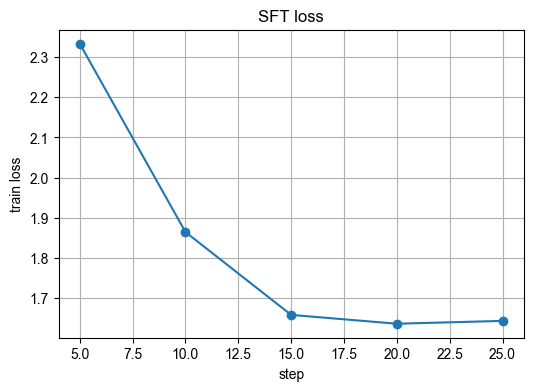

In [9]:
# ---- loss 曲线(看有没有学进去) ----
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "Heiti SC"]   # 让中文正常显示
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
logs = trainer.state.log_history        # 训练日志(列表,每项是字典)
steps = [x["step"] for x in logs if "loss" in x]   # 只挑含loss的记录
loss  = [x["loss"] for x in logs if "loss" in x]
os.makedirs(os.path.join(OUT, "figures"), exist_ok=True)
plt.figure(figsize=(6,4)); plt.plot(steps, loss, marker="o")
plt.xlabel("step"); plt.ylabel("train loss"); plt.title("SFT loss"); plt.grid(True)
plt.savefig(os.path.join(OUT, "figures", "sft_loss.png"), dpi=120, bbox_inches="tight"); plt.show()

In [10]:
# ---- 合并 LoRA 到底模，导出完整模型(后面DPO/评测用) ----
from peft import PeftModel
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)  # 重新加载干净底模
merged = PeftModel.from_pretrained(base, SFT_OUT).merge_and_unload()  # 装上补丁→合并成一体
merged.save_pretrained(SFT_MERGED); tokenizer.save_pretrained(SFT_MERGED)
print("SFT 合并模型已保存:", SFT_MERGED)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SFT 合并模型已保存: /Users/yunye/Documents/工作/项目/llm_sft_dpo_legalqa/outputs/sft_merged


In [11]:
# ---- 拿一条 eval 问题，看微调后的回答 ----
def generate(model, tokenizer, system, user, max_new_tokens=256):
    msgs = [{"role":"system","content":system},{"role":"user","content":user}]
    # apply_chat_template：按该模型规定的对话格式拼文本；add_generation_prompt=True=轮到模型说
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)   # 文本→id张量
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)  # do_sample=False=结果稳定
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()  # 切掉输入,只留生成

sft_eval = json.load(open(os.path.join(DATA, "sft_eval.json"), encoding="utf-8"))   # load读文件(loads读字符串)
sys_p = sft_eval[0]["messages"][0]["content"]
usr_p = sft_eval[0]["messages"][1]["content"]
print("问题:", usr_p)
print("参考:", sft_eval[0]["messages"][2]["content"][:100], "...")
print("SFT后:", generate(merged.to(DEVICE), tokenizer, sys_p, usr_p)[:200])

问题: 啥样算重婚罪的具体行为？
参考: 重婚罪的具体行为：
1.与配偶登记结婚，与他人又登记结婚而重婚，也即两个法律婚的重婚。有配偶的人又与他人登记结婚，有重婚者欺骗婚姻登记机关而领取结婚证的，也有重婚者和登记机关工作人员互相串通作弊领取结 ...
SFT后: 《刑法》第三百一十三条【重婚罪】有配偶又与他人结婚的，处五年以下有期徒刑或者拘役。有配偶而重婚的，或者明知他人有配偶而与之结婚的，处二年以下有期徒刑或者拘役。前款所称“配偶”，包括夫妻、情人、同居者、一夫多妻者中的男性与其妻子以及女性与其一夫多妻者中的男性。
